## Random Forest to Predict if an ECG Signal is Normal or Abnormal

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay


          0         1         2         3         4         5         6  \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

          7         8         9  ...  179  180  181  182  183  184  185  186  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   label  binary_label  
0    0.0             0  
1    0.0          

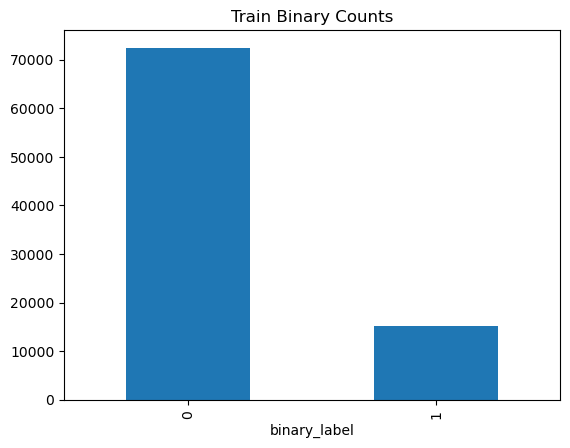

In [30]:
# Training data:
train = pd.read_csv('data/mitbih_train.csv', header=None)
train.columns = (list(range(187))) + ['label']
train['binary_label'] = np.where(train['label'] == 0, 0, 1)

x_train = train.drop(columns=['label', 'binary_label'])  # X
label = train['label']
y_train = train['binary_label'] # y

print(train.head())
y_train.value_counts().plot(kind='bar')
plt.title('Train Binary Counts')
plt.show()

          0         1         2         3         4         5         6  \
0  1.000000  0.758264  0.111570  0.000000  0.080579  0.078512  0.066116   
1  0.908425  0.783883  0.531136  0.362637  0.366300  0.344322  0.333333   
2  0.730088  0.212389  0.000000  0.119469  0.101770  0.101770  0.110619   
3  1.000000  0.910417  0.681250  0.472917  0.229167  0.068750  0.000000   
4  0.570470  0.399329  0.238255  0.147651  0.000000  0.003356  0.040268   

          7         8         9  ...  179  180  181  182  183  184  185  186  \
0  0.049587  0.047521  0.035124  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.307692  0.296703  0.300366  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.123894  0.115044  0.132743  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.004167  0.014583  0.054167  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.080537  0.070470  0.090604  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   label  binary_label  
0    0.0             0  
1    0.0          

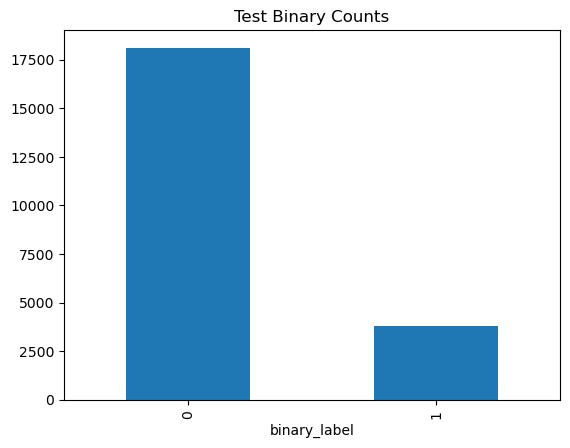

In [31]:
# Testing data:
test = pd.read_csv('data/mitbih_test.csv', header=None)
test.columns = (list(range(187))) + ['label']
test['binary_label'] = np.where(test['label'] == 0, 0, 1)

x_test = test.drop(columns=['label', 'binary_label'])
test_label = test['label']
y_test = test['binary_label']

print(test.head())
y_test.value_counts().plot(kind='bar')
plt.title('Test Binary Counts')
plt.show()

In [32]:
rf = RandomForestClassifier(n_estimators=100, random_state=123)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

In [33]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 97.78

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     18118
           1       0.99      0.88      0.93      3774

    accuracy                           0.98     21892
   macro avg       0.98      0.94      0.96     21892
weighted avg       0.98      0.98      0.98     21892



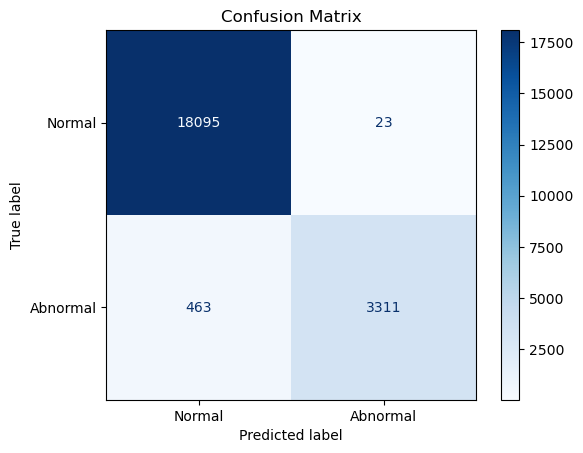

In [49]:
cm = confusion_matrix(y_test, y_pred)
signal = ['Normal', 'Abnormal']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=signal)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

ROC AUC Score: 0.9941


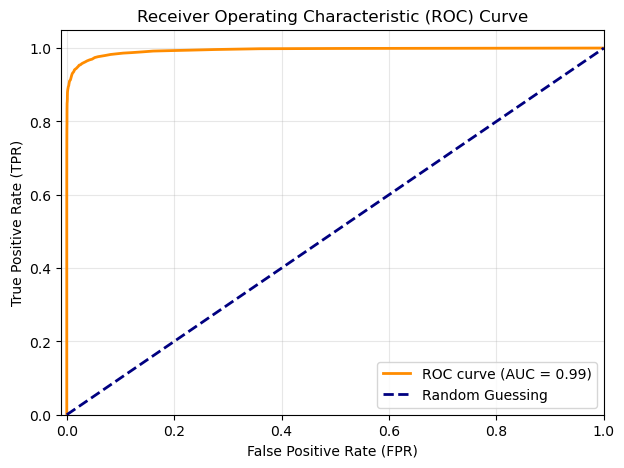

In [62]:
y_prob = rf.predict_proba(x_test)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

# Formatting details
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


Which parts of the ECG signal were most important for classifying normal vs abnormal heartbeats?

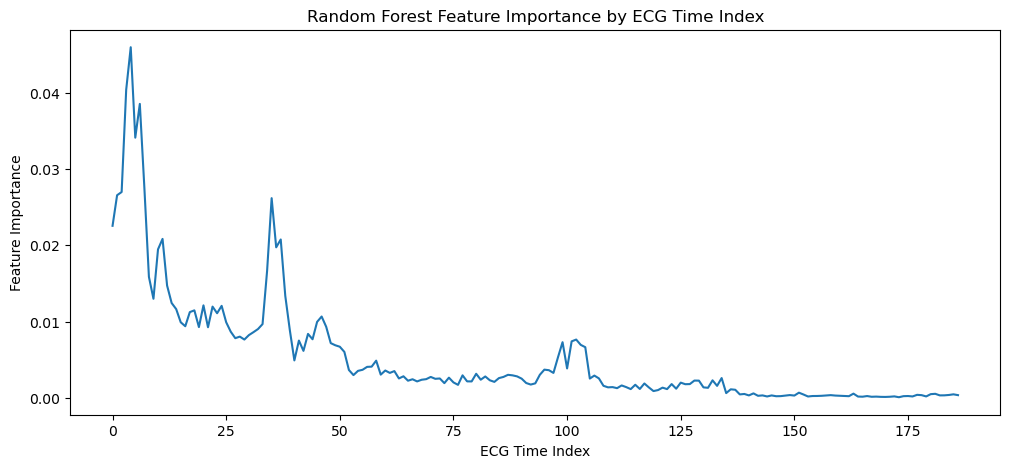

In [64]:
# Get feature importances from the random forest model
importances = rf.feature_importances_

# ECG time indices: 0, 1, 2, ..., 186
time_index = np.arange(len(importances))

plt.figure(figsize=(12, 5))
plt.plot(time_index, importances)

plt.xlabel("ECG Time Index")
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance by ECG Time Index")
plt.show()

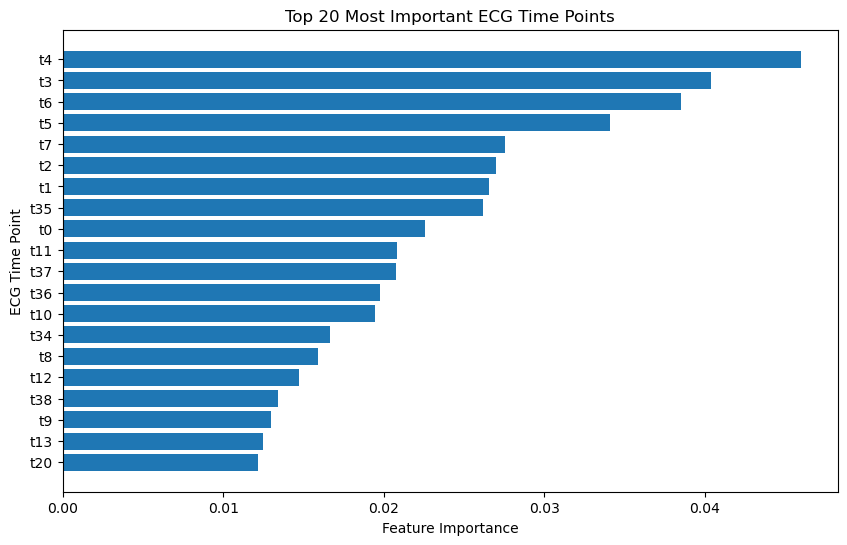

In [65]:
# Get indices of the top 20 most important features
top_n = 20
top_indices = np.argsort(importances)[-top_n:]

# Sort those top features from least to most important for plotting
top_indices_sorted = top_indices[np.argsort(importances[top_indices])]

plt.figure(figsize=(10, 6))
plt.barh(
    [f"t{idx}" for idx in top_indices_sorted],
    importances[top_indices_sorted]
)

plt.xlabel("Feature Importance")
plt.ylabel("ECG Time Point")
plt.title("Top 20 Most Important ECG Time Points")
plt.show()

### KNN Algorithm for fun

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [45]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_scaled, y_train)
y_pred_knn = knn.predict(x_test_scaled)

In [46]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn) * 100:.2f}%")

Accuracy: 97.89%


In [47]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_knn

array([[18002,   116],
       [  347,  3427]])